In [5]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (11055, 32)

Column Names:
['index', 'having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

First 5 Rows:


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [7]:
# Dataset Quality Check

print("=== DATASET QUALITY CHECK ===")

# 1. Missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# 2. Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# 3. Target distribution
print("\nTarget Distribution:")
print(df["Result"].value_counts())

# 4. Target percentages
print("\nTarget Distribution (%):")
print((df["Result"].value_counts(normalize=True) * 100).round(2))

# 5. Data types
print("\nData Types:")
print(df.dtypes.value_counts())

# 6. Basic statistics
print("\nBasic Statistics:")
display(df.describe().T)

=== DATASET QUALITY CHECK ===

Missing Values:
0

Duplicate Rows:
0

Target Distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64

Target Distribution (%):
Result
 1    55.69
-1    44.31
Name: proportion, dtype: float64

Data Types:
int64    32
Name: count, dtype: int64

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
index,11055.0,5528.000000,3191.447947,1.0,2764.5,5528.0,8291.5,11055.0
having_IPhaving_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URLURL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0


In [8]:
# ============================================
# DATA PREPARATION
# ============================================

from sklearn.model_selection import train_test_split

# Remove the index column because it is only an identifier
X = df.drop(columns=["index", "Result"])

# Target variable
y = df["Result"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Target classes:")
print(y.value_counts())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

Feature matrix shape: (11055, 30)
Target shape: (11055,)

Number of features: 30
Target classes:
Result
 1    6157
-1    4898
Name: count, dtype: int64

Training set: (8844, 30)
Testing set: (2211, 30)


In [9]:
# ============================================
# MACHINE LEARNING MODEL TRAINING
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

# Train each model
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} completed.\n")

print("===================================")
print("All 5 models trained successfully!")
print("===================================")

Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training Random Forest...
Random Forest completed.

Training SVM...
SVM completed.

Training KNN...
KNN completed.

All 5 models trained successfully!


In [10]:
# ============================================
# MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import pandas as pd

results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability/decision scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    # Convert target to 0/1 for ROC-AUC
    y_test_binary = (y_test == 1).astype(int)
    y_score_binary = y_score

    roc_auc = roc_auc_score(y_test_binary, y_score_binary)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create results table
results_df = pd.DataFrame(results)

# Display percentages
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_display = results_df.copy()

for metric in metrics:
    results_display[metric] = (
        results_display[metric] * 100
    ).round(2)

print("MODEL PERFORMANCE COMPARISON")
display(results_display)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,92.90,92.42,95.04,93.71,98.08
1,Decision Tree,97.11,97.02,97.81,97.41,98.05
2,Random Forest,97.42,97.11,98.29,97.70,99.78
3,SVM,94.89,94.02,96.99,95.48,98.96
4,KNN,94.66,94.77,95.69,95.23,98.53


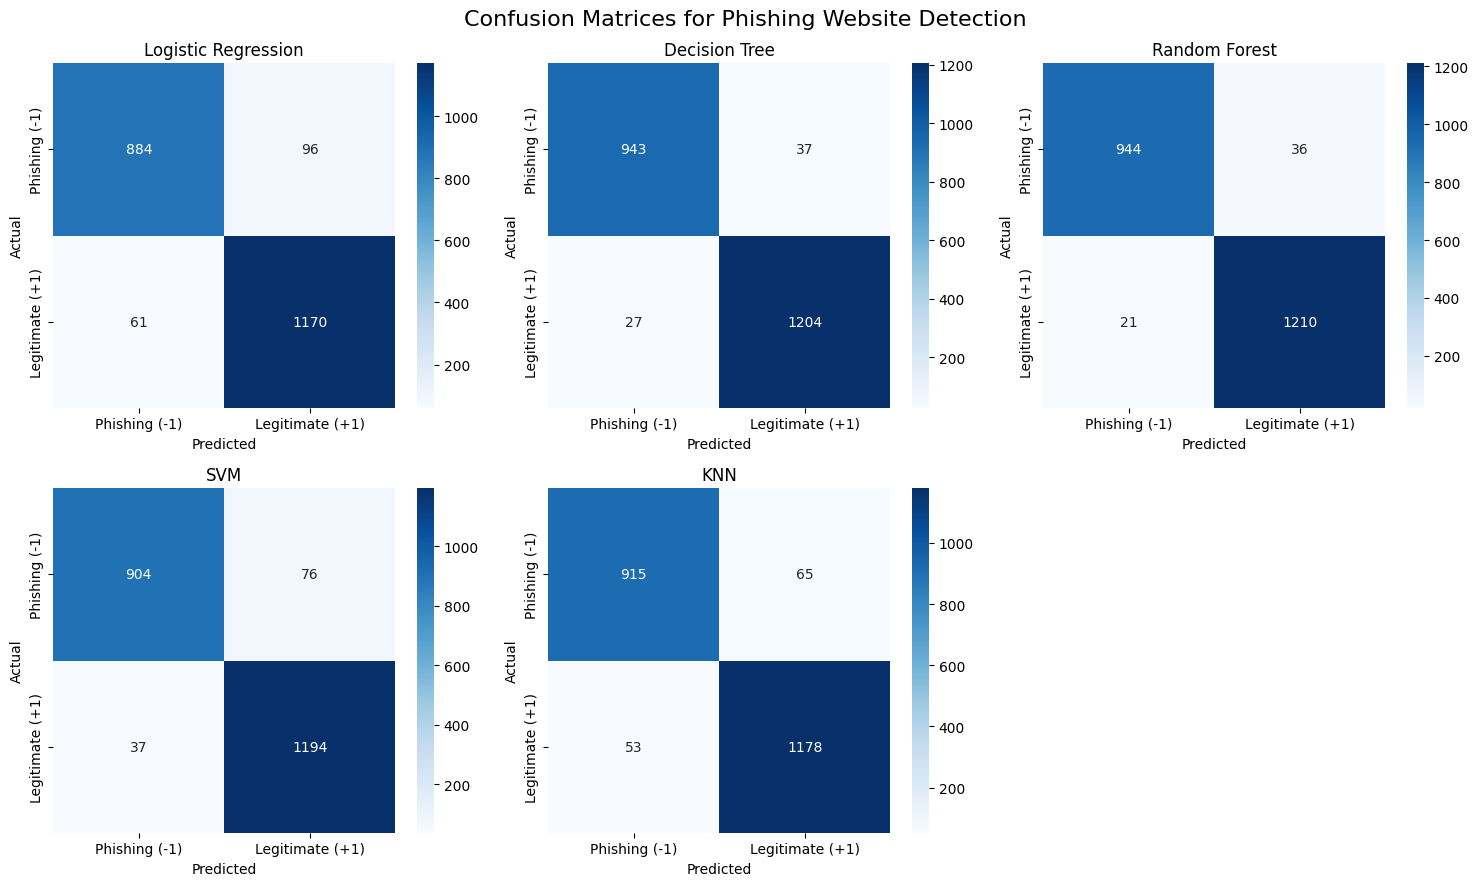

In [11]:
# ============================================
# CONFUSION MATRICES
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Phishing (-1)", "Legitimate (+1)"],
        yticklabels=["Phishing (-1)", "Legitimate (+1)"]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove unused subplot
if len(trained_models) < len(axes):
    for j in range(len(trained_models), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle("Confusion Matrices for Phishing Website Detection", fontsize=16)
plt.tight_layout()
plt.show()

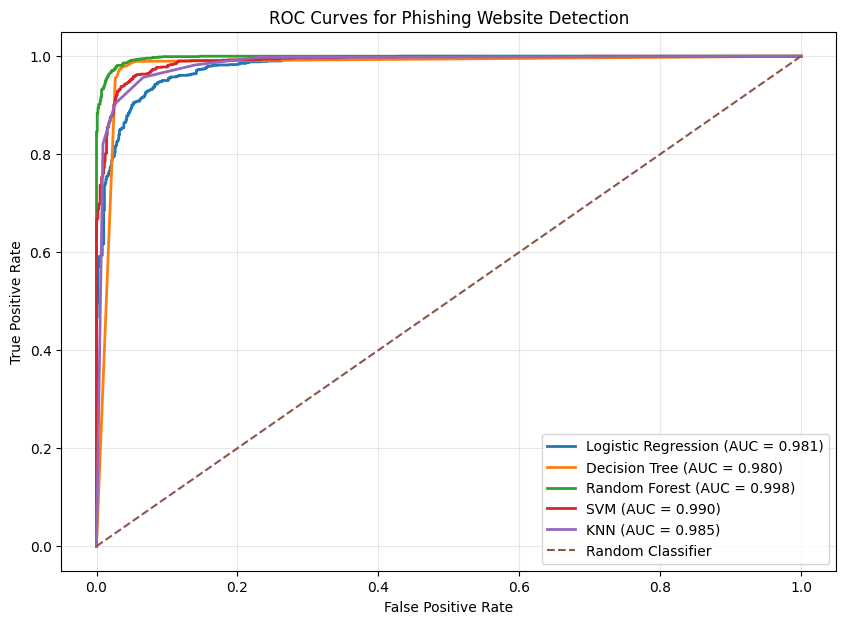

In [12]:
# ============================================
# ROC CURVES FOR ALL MODELS
# ============================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

y_test_binary = (y_test == 1).astype(int)

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test_binary, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Phishing Website Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Top 15 Most Important Features:


,Feature,Importance
7,SSLfinal_State,0.328533
13,URL_of_Anchor,0.238494
25,web_traffic,0.072147
6,having_Sub_Domain,0.067592
14,Links_in_tags,0.042919
5,Prefix_Suffix,0.041475
15,SFH,0.019914
28,Links_pointing_to_page,0.019529
12,Request_URL,0.018651
8,Domain_registeration_length,0.016281


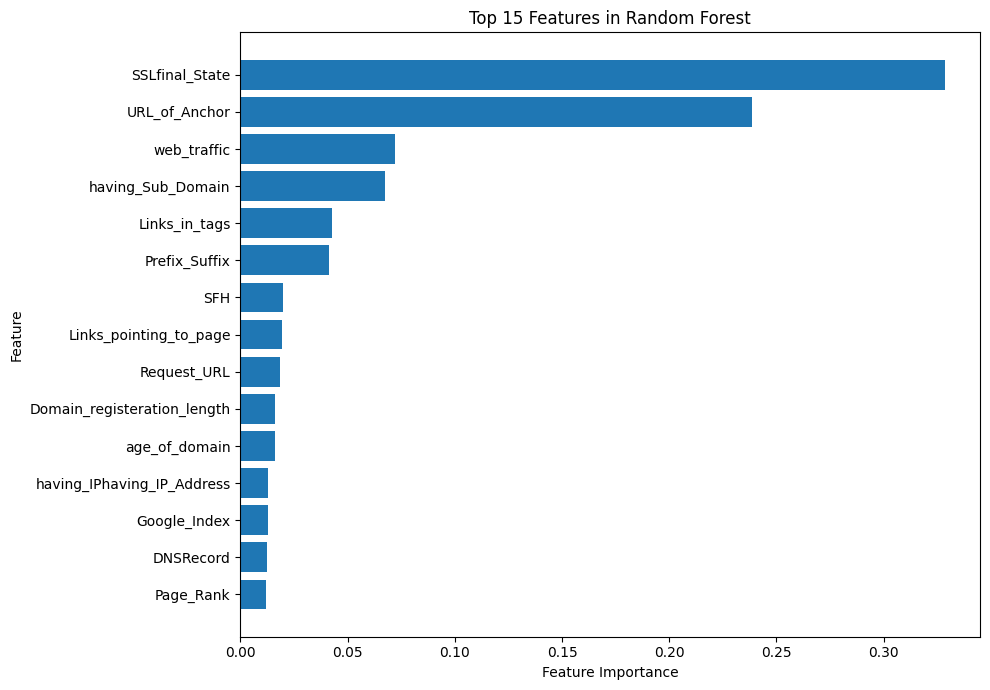

In [13]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Get the trained Random Forest model
rf_model = trained_models["Random Forest"]

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

# Plot top 15 features
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features in Random Forest")
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# SHAP EXPLAINABILITY ANALYSIS
# ============================================

!pip -q install shap

In [15]:
# ============================================
# RECOVER / RETRAIN THE MODELS
# ============================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
df = pd.read_csv("dataset.csv")

# Prepare features and target
X = df.drop(columns=["index", "Result"])
y = df["Result"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

# Train models
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\n===================================")
print("ALL MODELS RECOVERED SUCCESSFULLY")
print("===================================")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training KNN...

ALL MODELS RECOVERED SUCCESSFULLY


In [16]:
# ============================================
# FAST SHAP ANALYSIS
# ============================================

import shap

rf_model = trained_models["Random Forest"]

# Use only 500 test samples for SHAP
X_shap = X_test.sample(
    n=500,
    random_state=42
)

print("SHAP sample:", X_shap.shape)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed!")

SHAP sample: (500, 30)
SHAP calculation completed!


Original SHAP shape: (500, 30, 2)
X_shap shape: (500, 30)
SHAP shape used for plotting: (500, 30)


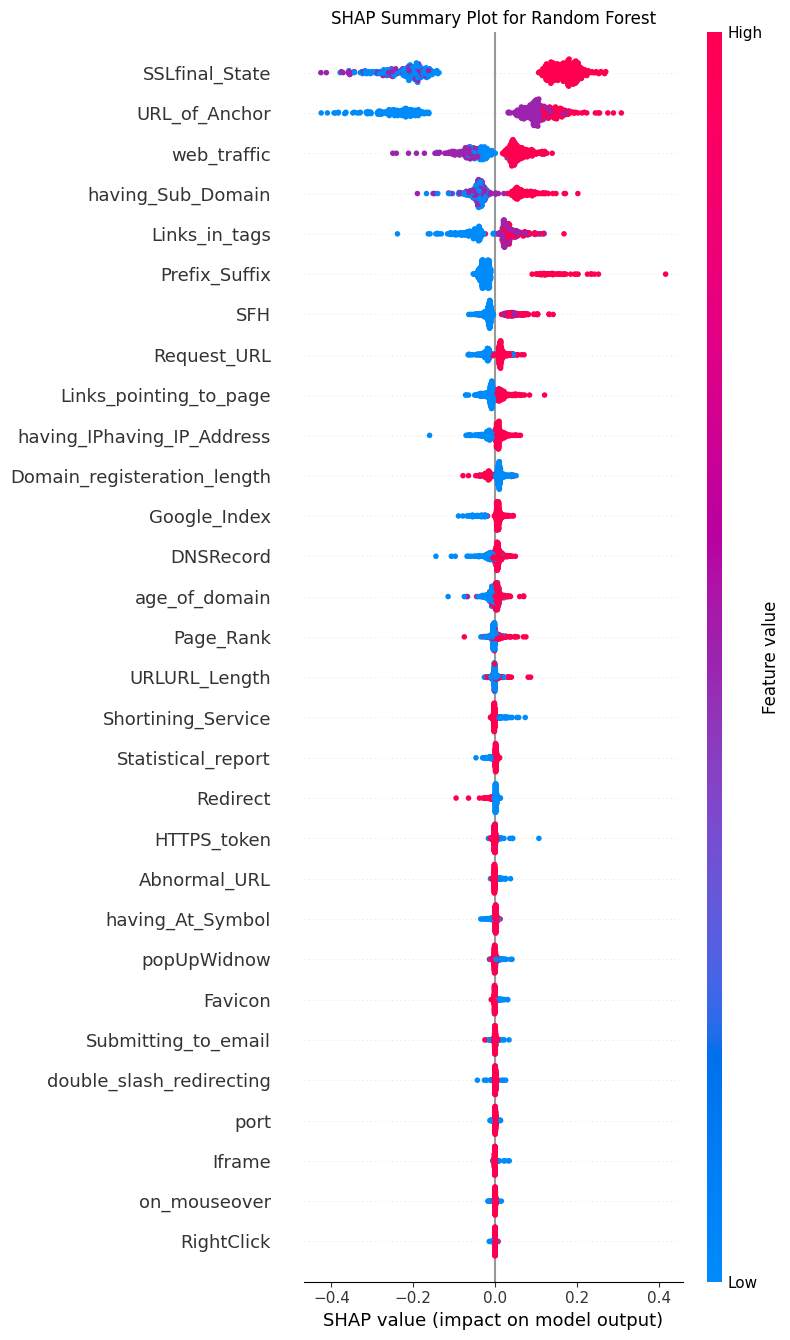

In [18]:
# ============================================
# CORRECT SHAP SUMMARY PLOT
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # Older SHAP versions:
    # [class_0_values, class_1_values]
    shap_plot_values = shap_values[1]

else:
    shap_plot_values = shap_values

# Convert to NumPy array
shap_plot_values = np.asarray(shap_plot_values)

print("Original SHAP shape:", shap_plot_values.shape)
print("X_shap shape:", X_shap.shape)

# Newer SHAP versions may return:
# (samples, features, classes)
# Select class 1 for the legitimate (+1) class
if shap_plot_values.ndim == 3:
    shap_plot_values = shap_plot_values[:, :, 1]

print("SHAP shape used for plotting:", shap_plot_values.shape)

# Generate the proper SHAP summary plot
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_plot_values,
    X_shap,
    feature_names=X_shap.columns,
    max_display=30,
    show=False
)

plt.title("SHAP Summary Plot for Random Forest")
plt.tight_layout()
plt.show()